In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import bayesflow as bf

In [7]:
def simple_heston(
    lambda_=1.0,
    rho=-0.7,
    nu=0.2,
    theta=0.04,
    V0=0.04,
    T=1.0,
    n=100,
    N=1,
    S0=1.0
):
    """
    Simulate the simple (standard) Heston model via Euler-Maruyama.

    The model is:
        dS_t = S_t sqrt(V_t) dW_t
        dV_t = lambda*(theta - V_t)*dt + lambda*nu*sqrt(V_t)*dB_t
    where <dW_t, dB_t> = rho dt.

    Feller condition (2*lambda*theta >= (lambda*nu)^2) must hold; an
    AssertionError is raised if it is violated.

    Parameters
    ----------
    lambda_ : float - Mean-reversion speed.
    rho     : float - Correlation between price and variance Brownians.
    nu      : float - Vol-of-vol (normalized); must satisfy nu <= sqrt(2*theta/lambda_).
    theta   : float - Long-run variance.
    V0      : float - Initial variance.
    T       : float - Maturity in years.
    n       : int   - Time steps per year.
    N       : int   - Number of Monte Carlo paths.
    S0      : float - Initial asset price.

    Returns
    -------
    S : ndarray, shape (N, 1+s) - Asset price paths.
    V : ndarray, shape (N, 1+s) - Variance paths.
    """
    # assert 2.0 * lambda_ * theta >= nu ** 2, (
    #     f"Feller condition violated: 2*lambda*theta={2*lambda_*theta:.4f} < "
    #     f"(lambda*nu)^2={nu**2:.4f}."
    # )

    s = int(n * T)
    dt = T / s
    sqrt_dt = np.sqrt(dt)

    dB = np.random.randn(N, s) * sqrt_dt
    dZ = np.random.randn(N, s) * sqrt_dt
    dW = rho * dB + np.sqrt(1.0 - rho**2) * dZ

    V_path = np.zeros((N, 1 + s))
    V_path[:, 0] = V0
    for i in range(s):
        V_prev = V_path[:, i]
        V_path[:, i + 1] = (V_prev
                            + lambda_ * (theta - V_prev) * dt
                            + nu * np.sqrt(np.maximum(V_prev, 0.0)) * dB[:, i])
        V_path[:, i + 1] = np.maximum(V_path[:, i + 1], 0.0)

    log_increments = -0.5 * V_path[:, :-1] * dt + np.sqrt(np.maximum(V_path[:, :-1], 0.0)) * dW
    log_S = np.zeros((N, 1 + s))
    log_S[:, 0] = np.log(S0)
    log_S[:, 1:] = np.log(S0) + np.cumsum(log_increments, axis=1)

    return {
        "price": np.exp(log_S).squeeze(),
        # "volatility": V_path.squeeze(),
    }


In [8]:
sim = simple_heston()
sim["price"].shape

(101,)

In [9]:
def priors():
    lambda_ = np.random.gamma(2, 0.5)        # mean=1.0, positive
    theta   = np.random.gamma(2, 0.02)       # mean=0.04, positive
    nu_max  = np.sqrt(2 * theta / lambda_)   # Feller ceiling: nu < nu_max guarantees 2λθ >= (λν)²
    nu      = np.random.uniform(0, nu_max)
    rho     = -np.random.beta(2, 2)         # in (-1, 0]
    V0      = np.random.gamma(2, theta / 2)  # mean=theta
    return {
        "lambda_": lambda_,
        "rho":     rho,
        "nu":      nu,
        "theta":   theta,
        "V0":      V0,
    }

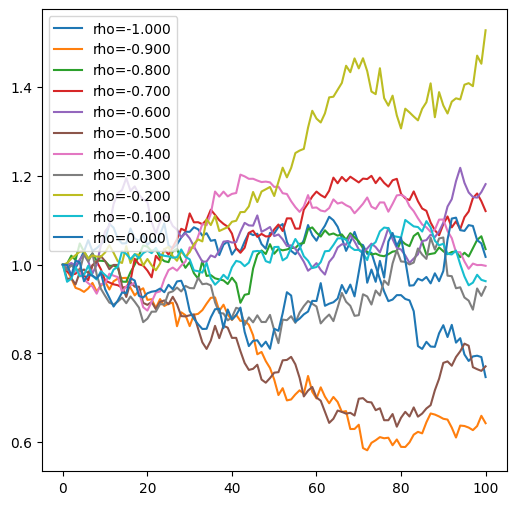

In [10]:
rhos = np.linspace(-1.0, 0, 11)
f, ax = plt.subplots(1, 1, figsize=(6, 6))
for i, rho in enumerate(rhos):
    prices = simple_heston(rho=rho)
    plt.plot(prices["price"], label="rho={:.3f}".format(rho))
    plt.legend()

In [11]:
simulator = bf.make_simulator([priors, simple_heston])

In [12]:
sims = simulator.sample(batch_shape=100)

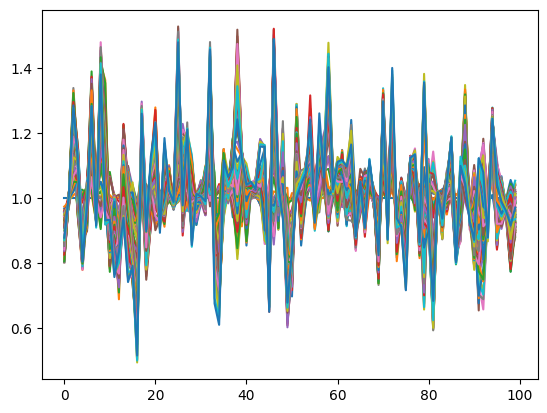

In [13]:
plt.plot(sims["price"])

In [14]:
for k, v in sims.items():
    print(k, v.shape)

lambda_ (100, 1)
rho (100, 1)
nu (100, 1)
theta (100, 1)
V0 (100, 1)
price (100, 101)


In [26]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate(["lambda_", "rho", "nu", "theta", "V0"], into="inference_variables")
    .expand_dims(["price"], axis=-1)
    .concatenate(["price"], axis=-1, into="summary_variables")
)

In [27]:
adapted_sims = adapter(simulator.sample(batch_shape=4))

In [28]:
for k, v in adapted_sims.items():
    print(k, v.shape)

inference_variables (4, 5)
summary_variables (4, 101, 1)


In [29]:
summary_net = bf.networks.TimeSeriesTransformer(summary_dim=16)
inference_net = bf.networks.FlowMatching()

In [30]:
workflow = bf.workflows.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_net,
    summary_network=summary_net,
    standardize="all"
)

In [35]:
training_set = workflow.simulate(25000)
val_set = workflow.simulate(500)

In [36]:
history = workflow.fit_offline(
    data=training_set,
    validation_data=val_set,
    epochs=100,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.


Epoch 1/100
 91/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1516

E0422 14:41:24.036020 3488058 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.27 = f32[808,64]{1,0} fusion(bitcast.1005, args_0__0__75_.1), kind=kCustom, calls=gemm_fusion_dot.27_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0422 14:41:24.036092 3488058 xtile_compiler.cc:401] Computation: gemm_fusion_dot.27_computation.clone {
  parameter_0.52 = f32[808,128]{1,0} parameter(0)
  constant_3621 = f32[] constant(1.05263162)
  broadcast.1314 = f32[808,128]{1,0} broadcast(constant_3621), dimensions={}
  multiply.1101 = f32[808,128]{1,0} multiply(parameter_0.52, broadcast.1314)
  parameter_1.52 = f32[64,128]{1,0} parameter(1

782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - loss: 1.1688 - val_loss: 1.1294
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1687 - val_loss: 1.1276
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1942 - val_loss: 1.1946
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2100 - val_loss: 1.2279
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.2123 - val_loss: 1.3081
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.2241 - val_loss: 1.1739
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.2147 - val_loss: 1.1697
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.2051 - val_loss: 1.1428
Epoch 9/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2140 - val_loss: 1.1945
Epoch 10/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2036 - val_loss: 1.0563
Epoch 11/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1922 - val_loss: 1.1149
Epoch 12/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/st

INFO:bayesflow:Training completed in 2.28 minutes.


Sampling: 100%|██████████| 1/1 [00:20<00:00, 20.76s/batch]


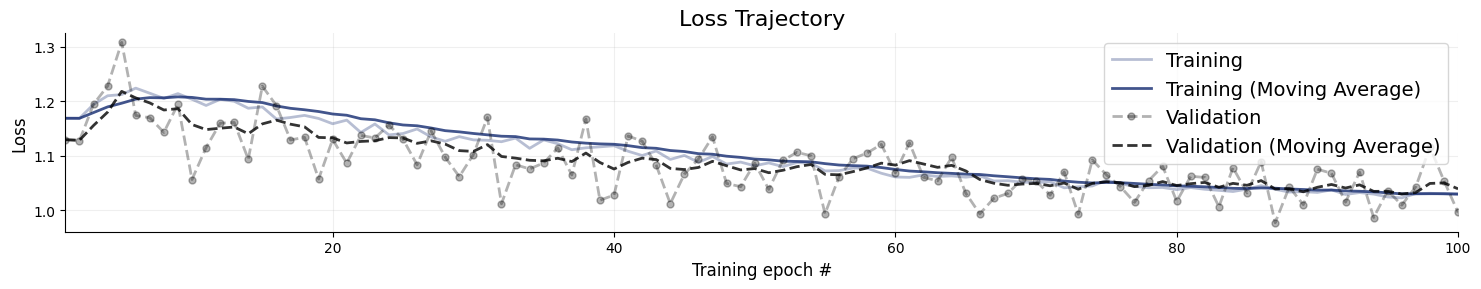

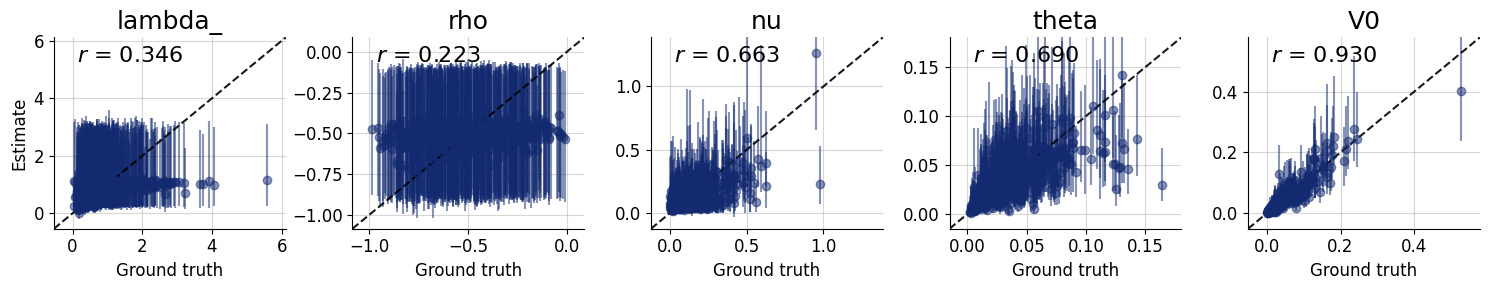

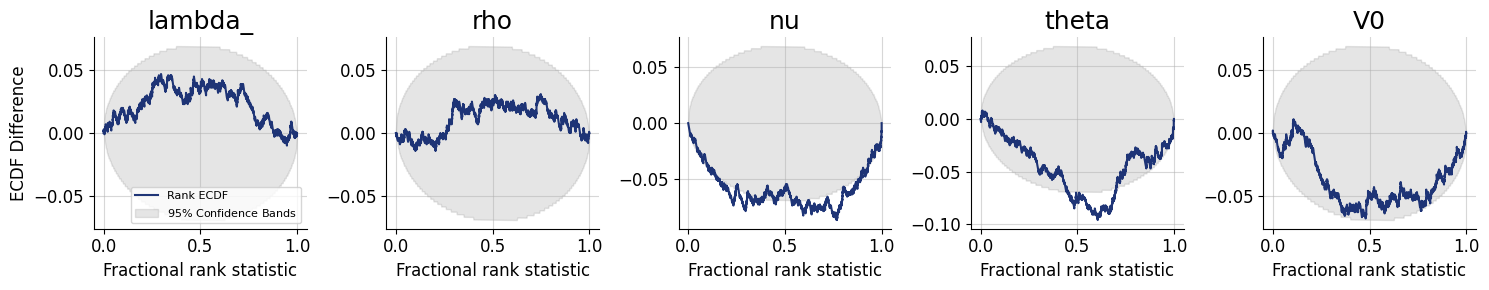

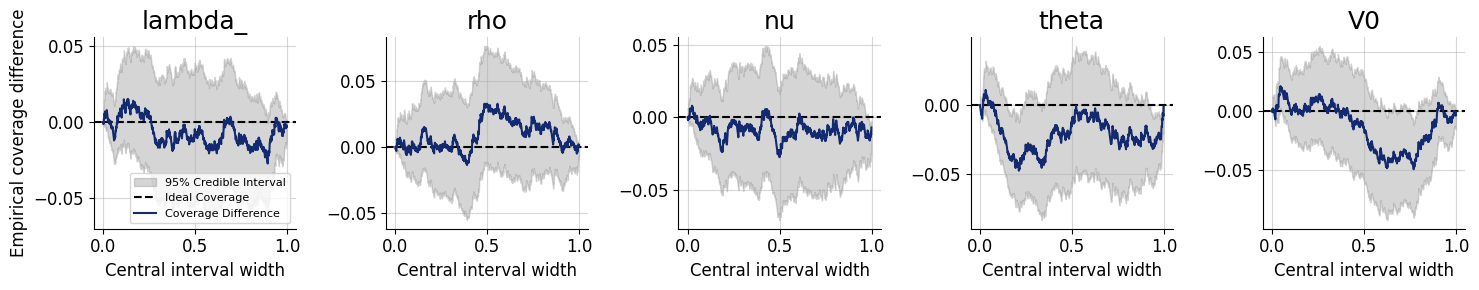

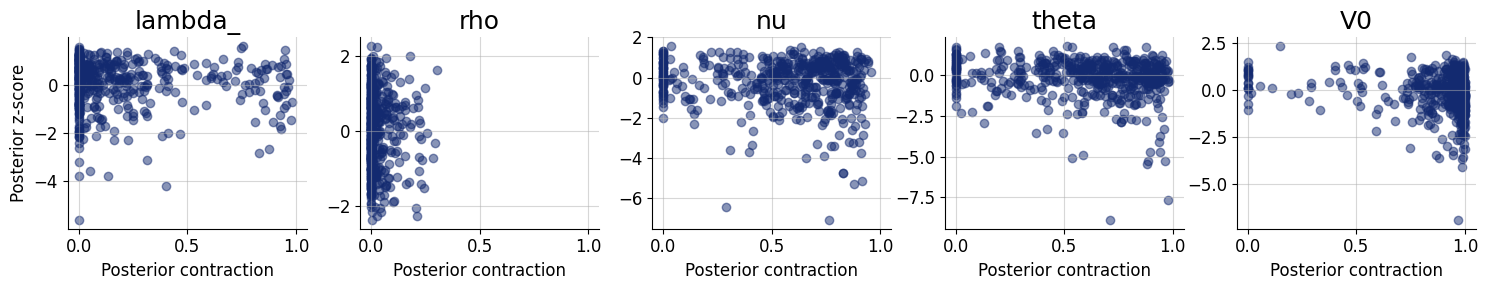

In [37]:
figures = workflow.plot_default_diagnostics(
    test_data=val_set,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    recovery_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": (15, 3), "legend_fontsize": 8, "label_fontsize": 12, "difference": True},
    coverage_kwargs={"figsize": (15, 3), "legend_fontsize": 8, "label_fontsize": 12, "difference": True},
    z_score_contraction_kwargs={"figsize": (15, 3), "label_fontsize": 12}
)